In [1]:
# Task 5: Decision Trees and Random Forests

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [2]:
# Load Dataset
df = pd.read_csv(r"C:\Users\thern\OneDrive\Desktop\ElevateLabs\heart.csv")

# Display first rows
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [3]:
# Features and Target
X = df.drop('target', axis=1)
y = df['target']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
#Decision Tree Classifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("\nDecision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy:
0.9853658536585366


In [5]:
#Control Overfitting using max_depth

dt_depth = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt_depth.fit(X_train, y_train)

y_pred_depth = dt_depth.predict(X_test)

print("\nDecision Tree Accuracy (max_depth=4):")
print(accuracy_score(y_test, y_pred_depth))



Decision Tree Accuracy (max_depth=4):
0.8


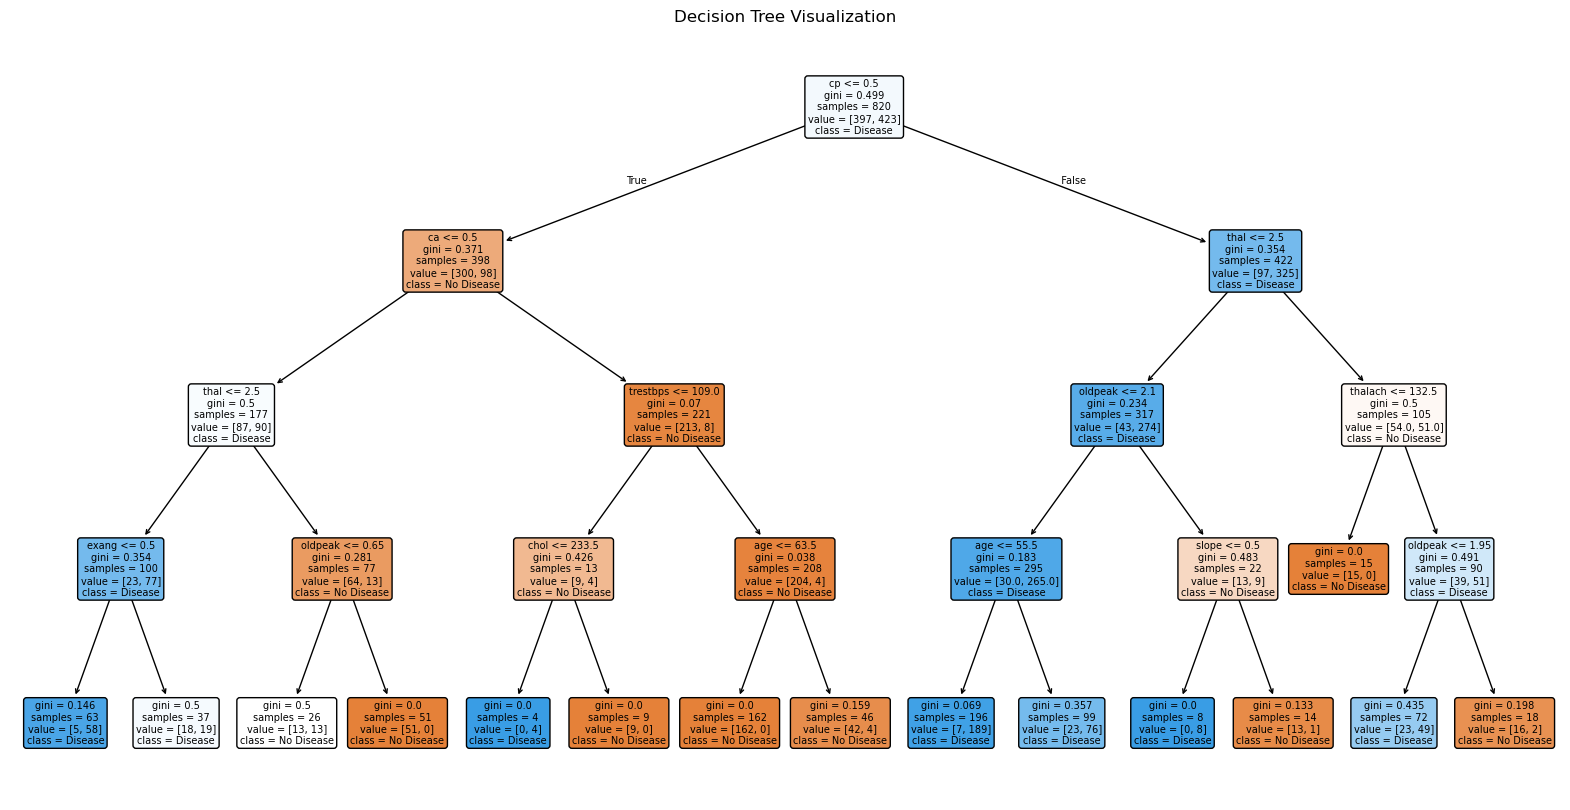

In [6]:
# 3. Visualize Decision Tree

plt.figure(figsize=(20,10))

plot_tree(
    dt_depth,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree Visualization")
plt.show()

In [7]:
# 4. Random Forest Classifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy:
0.9853658536585366

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205




Feature Importance:
     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


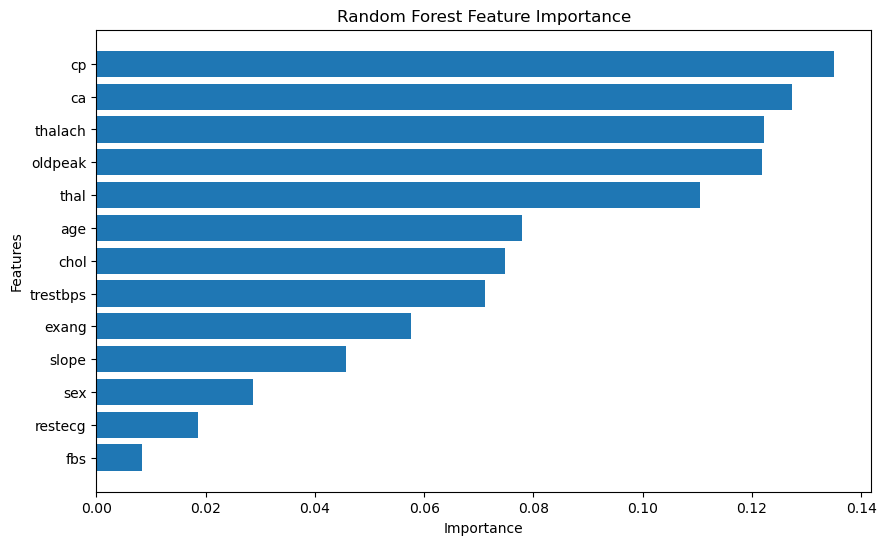

In [8]:
# 5. Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

# Plot Feature Importance
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.show()


In [9]:
# 6. Cross Validation

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("\nCross Validation Scores:")
print(cv_scores)

print("\nMean Cross Validation Accuracy:")
print(cv_scores.mean())


Cross Validation Scores:
[1.         1.         1.         1.         0.98536585]

Mean Cross Validation Accuracy:
0.9970731707317073
